# Chapter 4: Fairness, Bias Mitigation, and Production Monitoring

This notebook covers:
- **§4.2** Fairness Analysis (metrics, group-level evaluation)
- **§4.3** Bias Mitigation (reweighting, group thresholds, group calibration)
- **§4.4** Production Monitoring Framework

> **Prerequisite:** Run `ch3_modeling.ipynb` first to generate `models/improved_model_xgb.pkl`.

> **Note:** Protected attributes (race, gender) are synthetically generated for this exercise.
> Real credit models would use actual demographic data under strict regulatory controls.

## 4.2 Setup: Load Model and Generate Protected Attributes

### 4.2.1 Load Saved Model and Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, precision_score, 
    recall_score, f1_score, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

# Load the model from Section 2
print("Loading model and data...")
best_model = joblib.load('models/improved_model_xgb.pkl')

# Load metadata
with open('models/improved_model_metadata.json', 'r', encoding='utf-8') as f:
    metadata = json.load(f)

# Load feature list
with open('models/improved_feature_list.txt', 'r', encoding='utf-8') as f:
    top_features = [line.strip() for line in f.readlines()]

print(f"✓ Model loaded: {metadata['model_type']}")
print(f"✓ Features: {len(top_features)}")

# Load datasets
train = pd.read_csv('model_data/train.csv')
val = pd.read_csv('model_data/val.csv')
test = pd.read_csv('model_data/test.csv')

# Prepare feature matrices
X_train = train[top_features]
y_train = train['defaulted']
X_val = val[top_features]
y_val = val['defaulted']
X_test = test[top_features]
y_test = test['defaulted']

# Handle missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
imputer.fit(X_train)

X_val = pd.DataFrame(imputer.transform(X_val), columns=top_features, index=val.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=top_features, index=test.index)

# Generate predictions
y_prob_val = best_model.predict_proba(X_val)[:, 1]
y_prob_test = best_model.predict_proba(X_test)[:, 1]

# Use validation-optimized threshold from Section 2
threshold = metadata['optimal_threshold_validation']
y_pred_val = (y_prob_val >= threshold).astype(int)
y_pred_test = (y_prob_test >= threshold).astype(int)

print(f"\n{'='*70}")
print("DATA SUMMARY")
print(f"{'='*70}")
print(f"Validation: {len(y_val):,} samples ({y_val.mean():.1%} default rate)")
print(f"Test:       {len(y_test):,} samples ({y_test.mean():.1%} default rate)")
print(f"Threshold:  {threshold:.2f}")

Loading model and data...
✓ Model loaded: XGBoost
✓ Features: 30

DATA SUMMARY
Validation: 477 samples (3.4% default rate)
Test:       463 samples (6.5% default rate)
Threshold:  0.20


### 4.2.2 Generate Synthetic Protected Attributes

Since our synthetic data doesn't include race or gender, we generate these
to demonstrate fairness analysis. In production, these would come from
HMDA or application data, subject to ECOA/FCRA requirements.

In [3]:
print("\n" + "="*70)
print("GENERATING SYNTHETIC PROTECTED ATTRIBUTES")
print("="*70)

def generate_protected_attributes(df, seed=42):
    """
    Generate synthetic protected attributes correlated with features.
    
    This simulates realistic patterns where protected attributes
    correlate with features like income, location, etc.
    """
    np.random.seed(seed)
    n = len(df)
    
    # Generate race - correlated with income if available
    # Higher income slightly more likely to be White (reflects historical inequality)
    if 'income' in df.columns:
        income_normalized = (df['income'] - df['income'].min()) / (df['income'].max() - df['income'].min())
        white_prob = 0.5 + 0.2 * income_normalized  # 50-70% White depending on income
    else:
        white_prob = np.full(n, 0.6)  # Default 60% White
    
    race_random = np.random.random(n)
    race = np.where(race_random < white_prob, 'White', 
           np.where(race_random < white_prob + 0.2, 'Black',
           np.where(race_random < white_prob + 0.3, 'Hispanic', 'Asian')))
    
    # Generate gender - roughly 50/50
    gender = np.random.choice(['Male', 'Female'], size=n, p=[0.52, 0.48])
    
    # Generate age groups
    if 'age' in df.columns:
        age = df['age'].values
    else:
        age = np.random.normal(42, 12, n).clip(18, 80)
    
    age_group = pd.cut(age, bins=[0, 25, 35, 45, 55, 65, 100], 
                       labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])
    
    return pd.DataFrame({
        'race': race,
        'gender': gender,
        'age_group': age_group.astype(str)
    }, index=df.index)

# Generate for validation and test sets
protected_val = generate_protected_attributes(val, seed=42)
protected_test = generate_protected_attributes(test, seed=43)

# Quick summary
print("\nValidation Set Demographics:")
print(f"  Race distribution:")
for race in ['White', 'Black', 'Hispanic', 'Asian']:
    count = (protected_val['race'] == race).sum()
    pct = count / len(protected_val) * 100
    print(f"    {race}: {count} ({pct:.1f}%)")

print(f"\n  Gender distribution:")
for gender in ['Male', 'Female']:
    count = (protected_val['gender'] == gender).sum()
    pct = count / len(protected_val) * 100
    print(f"    {gender}: {count} ({pct:.1f}%)")

print("\nTest Set Demographics:")
print(f"  Race distribution:")
for race in ['White', 'Black', 'Hispanic', 'Asian']:
    count = (protected_test['race'] == race).sum()
    pct = count / len(protected_test) * 100
    print(f"{race}: {count} ({pct:.1f})%")


GENERATING SYNTHETIC PROTECTED ATTRIBUTES

Validation Set Demographics:
  Race distribution:
    White: 280 (58.7%)
    Black: 97 (20.3%)
    Hispanic: 50 (10.5%)
    Asian: 50 (10.5%)

  Gender distribution:
    Male: 252 (52.8%)
    Female: 225 (47.2%)

Test Set Demographics:
  Race distribution:
White: 276 (59.6)%
Black: 83 (17.9)%
Hispanic: 50 (10.8)%
Asian: 54 (11.7)%


## 4.2.3 Fairness Metric Definitions

We implement four key fairness metrics used in credit scoring:

**Disparate Impact Ratio (DIR)** — The 4/5ths rule from ECOA enforcement

In [4]:
def disparate_impact_ratio(y_pred, protected_attr, unprivileged_value, privileged_value):
    """
    Disparate Impact Ratio: Are approval rates equal across groups?
    
    DIR = P(approved | unprivileged) / P(approved | privileged)
    
    In credit scoring: y_pred=1 means "default" (deny), y_pred=0 means "no default" (approve)
    So approval means y_pred == 0
    
    Returns:
        float: Ratio of approval rates (1.0 = perfect parity)
    Interpretation:
        DIR >= 0.80: Passes 4/5ths rule
        DIR < 0.80: Potential disparate impact violation
    """
    unprivileged_mask = (protected_attr == unprivileged_value)
    privileged_mask = (protected_attr == privileged_value)
    
    # Approval = predict no default (y_pred == 0)
    unprivileged_approval_rate = (y_pred[unprivileged_mask] == 0).mean()
    privileged_approval_rate = (y_pred[privileged_mask] == 0).mean()
    
    if privileged_approval_rate == 0:
        return np.nan
    
    return unprivileged_approval_rate / privileged_approval_rate

**Statistical Parity Difference (SPD)** — Difference in approval rates

In [5]:
def statistical_parity_difference(y_pred, protected_attr, unprivileged_value, privileged_value):
    """
    Statistical Parity Difference: Difference in approval rates.
    
    SPD = P(approved | unprivileged) - P(approved | privileged)
    
    Returns:
        float: Difference in approval rates (0.0 = perfect parity)
    Interpretation:
        SPD = 0: Perfect parity
        SPD < 0: Unprivileged group approved less often
        |SPD| > 0.1: Substantial disparity
    """
    unprivileged_mask = (protected_attr == unprivileged_value)
    privileged_mask = (protected_attr == privileged_value)
    
    unprivileged_approval = (y_pred[unprivileged_mask] == 0).mean()
    privileged_approval = (y_pred[privileged_mask] == 0).mean()
    
    return unprivileged_approval - privileged_approval

**Equal Opportunity Difference (EOD)** — Difference in true positive rates

In [6]:
def equal_opportunity_difference(y_true, y_pred, protected_attr, unprivileged_value, privileged_value):
    """
    Equal Opportunity Difference: Difference in True Positive Rates.
    
    Among people who actually default, is the model equally good at catching them?
    
    EOD = TPR_unprivileged - TPR_privileged
    
    Returns:
        float: Difference in TPR (0.0 = perfect equality)
    Interpretation:
        |EOD| < 0.05: Good
        |EOD| 0.05-0.10: Moderate disparity
        |EOD| > 0.10: Significant disparity
    """
    def tpr(y_true_group, y_pred_group):
        if len(y_true_group) == 0:
            return np.nan
        cm = confusion_matrix(y_true_group, y_pred_group, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        return tp / (tp + fn) if (tp + fn) > 0 else np.nan
    
    unprivileged_mask = (protected_attr == unprivileged_value)
    privileged_mask = (protected_attr == privileged_value)
    
    tpr_unprivileged = tpr(y_true[unprivileged_mask], y_pred[unprivileged_mask])
    tpr_privileged = tpr(y_true[privileged_mask], y_pred[privileged_mask])
    
    if np.isnan(tpr_unprivileged) or np.isnan(tpr_privileged):
        return np.nan
    
    return tpr_unprivileged - tpr_privileged

**Average Odds Difference (AOD)** — Average of TPR and FPR differences

In [7]:
def average_odds_difference(y_true, y_pred, protected_attr, unprivileged_value, privileged_value):
    """
    Average Odds Difference: Average of |TPR diff| and |FPR diff|.
    
    Captures unfairness in BOTH types of errors.
    
    AOD = 0.5 × (|TPR_diff| + |FPR_diff|)
    
    Returns:
        float: Average of absolute differences (0.0 = perfect equality)
    Interpretation:
        AOD < 0.05: Good
        AOD 0.05-0.10: Moderate disparity
        AOD > 0.10: Significant disparity
    """
    def rates(y_true_group, y_pred_group):
        if len(y_true_group) == 0:
            return np.nan, np.nan
        cm = confusion_matrix(y_true_group, y_pred_group, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        return tpr, fpr
    
    unprivileged_mask = (protected_attr == unprivileged_value)
    privileged_mask = (protected_attr == privileged_value)
    
    tpr_unpriv, fpr_unpriv = rates(y_true[unprivileged_mask], y_pred[unprivileged_mask])
    tpr_priv, fpr_priv = rates(y_true[privileged_mask], y_pred[privileged_mask])
    
    if any(np.isnan([tpr_unpriv, fpr_unpriv, tpr_priv, fpr_priv])):
        return np.nan
    
    tpr_diff = abs(tpr_unpriv - tpr_priv)
    fpr_diff = abs(fpr_unpriv - fpr_priv)
    
    return 0.5 * (tpr_diff + fpr_diff)

**Expected Calibration Error (ECE)** — How honest are the probabilities?

In [8]:

def expected_calibration_error(y_true, y_prob, n_bins=10):
    """
    Expected Calibration Error: How "honest" are the predictions?
    
    Does predicted 15% actually mean 15% default?
    
    ECE = Σ (bin_weight × |predicted_rate - actual_rate|)
    
    Returns:
        float: Weighted average calibration error (0.0 = perfect calibration)
    Interpretation:
        ECE < 0.05: Well calibrated
        ECE 0.05-0.10: Moderate miscalibration
        ECE > 0.10: Poorly calibrated
    """
    if len(y_true) == 0:
        return np.nan
    
    bins = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(y_prob, bins) - 1
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)
    
    ece = 0
    for i in range(n_bins):
        in_bin = (bin_indices == i)
        
        if in_bin.sum() > 0:
            bin_accuracy = y_true[in_bin].mean()
            bin_confidence = y_prob[in_bin].mean()
            bin_weight = in_bin.sum() / len(y_true)
            
            ece += bin_weight * abs(bin_accuracy - bin_confidence)
    
    return ece

**Group-Level Performance Metrics** — Helper to compute all metrics per group

In [9]:
def get_group_metrics(y_true, y_pred, y_prob, protected_attr, group_value):
    """
    Calculate all performance metrics for a specific group.
    """
    mask = (protected_attr == group_value)
    n = mask.sum()
    
    if n == 0:
        return {'n': 0}
    
    y_true_g = y_true[mask]
    y_pred_g = y_pred[mask]
    y_prob_g = y_prob[mask]
    
    # Basic counts
    cm = confusion_matrix(y_true_g, y_pred_g, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    metrics = {
        'n': n,
        'n_defaults': int(y_true_g.sum()),
        'default_rate': y_true_g.mean(),
        'approval_rate': (y_pred_g == 0).mean(),
        'denial_rate': (y_pred_g == 1).mean(),
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
        'TPR': tp / (tp + fn) if (tp + fn) > 0 else np.nan,
        'FPR': fp / (fp + tn) if (fp + tn) > 0 else np.nan,
        'TNR': tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        'FNR': fn / (fn + tp) if (fn + tp) > 0 else np.nan,
        'precision': tp / (tp + fp) if (tp + fp) > 0 else np.nan,
        'recall': tp / (tp + fn) if (tp + fn) > 0 else np.nan,
        'mean_prob': y_prob_g.mean(),
        'ECE': expected_calibration_error(y_true_g, y_prob_g)
    }
    
    return metrics

print("✓ All fairness metric functions defined")

✓ All fairness metric functions defined


---
## 4.2.4 Fairness Analysis: Race

### Validation Set

In [10]:
print("\n" + "="*70)
print("FAIRNESS ANALYSIS: RACE")
print("="*70)

# Convert to numpy arrays for consistent indexing
race_val = protected_val['race'].values
race_test = protected_test['race'].values
y_true_val = y_val.values
y_true_test = y_test.values

# Define groups
privileged_race = 'White'
unprivileged_races = ['Black', 'Hispanic', 'Asian']

# ============================================================
# VALIDATION SET ANALYSIS
# ============================================================
print("\n" + "-"*70)
print("VALIDATION SET")
print("-"*70)

# Group-level metrics
print("\nGroup-Level Performance Metrics:")
print("="*70)

val_race_metrics = {}
for race in ['White', 'Black', 'Hispanic', 'Asian']:
    val_race_metrics[race] = get_group_metrics(
        y_true_val, y_pred_val, y_prob_val, race_val, race
    )

# Create summary table
summary_data = []
for race, metrics in val_race_metrics.items():
    if metrics['n'] > 0:
        summary_data.append({
            'Race': race,
            'N': metrics['n'],
            'Default Rate': f"{metrics['default_rate']:.1%}",
            'Approval Rate': f"{metrics['approval_rate']:.1%}",
            'TPR': f"{metrics['TPR']:.1%}" if not np.isnan(metrics['TPR']) else 'N/A',
            'FPR': f"{metrics['FPR']:.1%}" if not np.isnan(metrics['FPR']) else 'N/A',
            'ECE': f"{metrics['ECE']:.3f}" if not np.isnan(metrics['ECE']) else 'N/A'
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Calculate fairness metrics vs White (privileged group)
print("\n\nFairness Metrics (vs White as privileged group):")
print("="*70)

fairness_results_val = []
for race in unprivileged_races:
    dir_val = disparate_impact_ratio(y_pred_val, race_val, race, privileged_race)
    spd_val = statistical_parity_difference(y_pred_val, race_val, race, privileged_race)
    eod_val = equal_opportunity_difference(y_true_val, y_pred_val, race_val, race, privileged_race)
    aod_val = average_odds_difference(y_true_val, y_pred_val, race_val, race, privileged_race)
    
    fairness_results_val.append({
        'Comparison': f'{race} vs White',
        'DIR': dir_val,
        'DIR Status': '✓' if dir_val >= 0.8 else '✗' if not np.isnan(dir_val) else 'N/A',
        'SPD': spd_val,
        'EOD': eod_val,
        'AOD': aod_val
    })

fairness_df_val = pd.DataFrame(fairness_results_val)
print("\nDisparate Impact Ratio (DIR) - 4/5ths Rule:")
print("  DIR >= 0.80: Passes | DIR < 0.80: Potential violation")
for _, row in fairness_df_val.iterrows():
    status = row['DIR Status']
    print(f"  {row['Comparison']}: {row['DIR']:.3f} {status}")

print("\nStatistical Parity Difference (SPD):")
print("  SPD = 0: Perfect | |SPD| > 0.1: Substantial disparity")
for _, row in fairness_df_val.iterrows():
    spd = row['SPD']
    status = '✓' if abs(spd) < 0.1 else '✗'
    print(f"  {row['Comparison']}: {spd:+.3f} {status}")

print("\nEqual Opportunity Difference (EOD) - TPR difference:")
print("  |EOD| < 0.05: Good | |EOD| > 0.10: Significant disparity")
for _, row in fairness_df_val.iterrows():
    eod = row['EOD']
    if np.isnan(eod):
        print(f"  {row['Comparison']}: N/A (insufficient data)")
    else:
        status = '✓' if abs(eod) < 0.1 else '✗'
        print(f"  {row['Comparison']}: {eod:+.3f} {status}")

print("\nAverage Odds Difference (AOD) - Combined TPR+FPR:")
print("  AOD < 0.05: Good | AOD > 0.10: Significant disparity")
for _, row in fairness_df_val.iterrows():
    aod = row['AOD']
    if np.isnan(aod):
        print(f"  {row['Comparison']}: N/A (insufficient data)")
    else:
        status = '✓' if aod < 0.1 else '✗'
        print(f"  {row['Comparison']}: {aod:.3f} {status}")


FAIRNESS ANALYSIS: RACE

----------------------------------------------------------------------
VALIDATION SET
----------------------------------------------------------------------

Group-Level Performance Metrics:
    Race   N Default Rate Approval Rate   TPR   FPR   ECE
   White 280         3.9%         91.4% 18.2%  8.2% 0.041
   Black  97         1.0%         90.7%  0.0%  9.4% 0.066
Hispanic  50         8.0%         92.0% 50.0%  4.3% 0.042
   Asian  50         0.0%         90.0%   N/A 10.0% 0.071


Fairness Metrics (vs White as privileged group):

Disparate Impact Ratio (DIR) - 4/5ths Rule:
  DIR >= 0.80: Passes | DIR < 0.80: Potential violation
  Black vs White: 0.992 ✓
  Hispanic vs White: 1.006 ✓
  Asian vs White: 0.984 ✓

Statistical Parity Difference (SPD):
  SPD = 0: Perfect | |SPD| > 0.1: Substantial disparity
  Black vs White: -0.007 ✓
  Hispanic vs White: +0.006 ✓
  Asian vs White: -0.014 ✓

Equal Opportunity Difference (EOD) - TPR difference:
  |EOD| < 0.05: Good | |EOD|

### Test Set

In [11]:
print("\n" + "-"*70)
print("TEST SET")
print("-"*70)

# Group-level metrics
print("\nGroup-Level Performance Metrics:")
print("="*70)

test_race_metrics = {}
for race in ['White', 'Black', 'Hispanic', 'Asian']:
    test_race_metrics[race] = get_group_metrics(
        y_true_test, y_pred_test, y_prob_test, race_test, race
    )

# Create summary table
summary_data_test = []
for race, metrics in test_race_metrics.items():
    if metrics['n'] > 0:
        summary_data_test.append({
            'Race': race,
            'N': metrics['n'],
            'Default Rate': f"{metrics['default_rate']:.1%}",
            'Approval Rate': f"{metrics['approval_rate']:.1%}",
            'TPR': f"{metrics['TPR']:.1%}" if not np.isnan(metrics['TPR']) else 'N/A',
            'FPR': f"{metrics['FPR']:.1%}" if not np.isnan(metrics['FPR']) else 'N/A',
            'ECE': f"{metrics['ECE']:.3f}" if not np.isnan(metrics['ECE']) else 'N/A'
        })

summary_df_test = pd.DataFrame(summary_data_test)
print(summary_df_test.to_string(index=False))

# Calculate fairness metrics
print("\n\nFairness Metrics (vs White as privileged group):")
print("="*70)

fairness_results_test = []
for race in unprivileged_races:
    dir_test = disparate_impact_ratio(y_pred_test, race_test, race, privileged_race)
    spd_test = statistical_parity_difference(y_pred_test, race_test, race, privileged_race)
    eod_test = equal_opportunity_difference(y_true_test, y_pred_test, race_test, race, privileged_race)
    aod_test = average_odds_difference(y_true_test, y_pred_test, race_test, race, privileged_race)
    
    fairness_results_test.append({
        'Comparison': f'{race} vs White',
        'DIR': dir_test,
        'SPD': spd_test,
        'EOD': eod_test,
        'AOD': aod_test
    })

# Print test results
for result in fairness_results_test:
    print(f"\n{result['Comparison']}:")
    print(f"  DIR: {result['DIR']:.3f} {'✓' if result['DIR'] >= 0.8 else '✗'}")
    print(f"  SPD: {result['SPD']:+.3f} {'✓' if abs(result['SPD']) < 0.1 else '✗'}")
    if not np.isnan(result['EOD']):
        print(f"  EOD: {result['EOD']:+.3f} {'✓' if abs(result['EOD']) < 0.1 else '✗'}")
    if not np.isnan(result['AOD']):
        print(f"  AOD: {result['AOD']:.3f} {'✓' if result['AOD'] < 0.1 else '✗'}")


----------------------------------------------------------------------
TEST SET
----------------------------------------------------------------------

Group-Level Performance Metrics:
    Race   N Default Rate Approval Rate   TPR  FPR   ECE
   White 276         6.2%         95.7% 17.6% 3.5% 0.019
   Black  83         9.6%         95.2%  0.0% 5.3% 0.064
Hispanic  50         6.0%         96.0%  0.0% 4.3% 0.047
   Asian  54         3.7%         94.4%  0.0% 5.8% 0.030


Fairness Metrics (vs White as privileged group):

Black vs White:
  DIR: 0.995 ✓
  SPD: -0.005 ✓
  EOD: -0.176 ✗
  AOD: 0.098 ✓

Hispanic vs White:
  DIR: 1.004 ✓
  SPD: +0.003 ✓
  EOD: -0.176 ✗
  AOD: 0.092 ✓

Asian vs White:
  DIR: 0.987 ✓
  SPD: -0.012 ✓
  EOD: -0.176 ✗
  AOD: 0.100 ✓


> **📌 Teaching Note: Equal Approval ≠ Equal Treatment.** DIR and SPD pass easily — approval rates are roughly equal across groups. But EOD fails: the model catches 0% of minority defaults on test (vs 17.6% White). Minority borrowers who are about to default get approved for loans they can't repay. That's harm through apparent approval.
>
> **⚠️ Small Sample Caveat:** These equal opportunity metrics are based on very small default counts per group (1–8 actual defaults). One more or fewer default would swing EOD dramatically. In production, you'd need larger samples before drawing conclusions about differential TPR.

## 4.2.5 Fairness Analysis: Gender

### Validation Set

In [12]:
print("\n" + "="*70)
print("FAIRNESS ANALYSIS: GENDER")
print("="*70)

gender_val = protected_val['gender'].values
gender_test = protected_test['gender'].values

privileged_gender = 'Male'
unprivileged_gender = 'Female'

# Validation set
print("\n" + "-"*70)
print("VALIDATION SET")
print("-"*70)

val_gender_metrics = {}
for gender in ['Male', 'Female']:
    val_gender_metrics[gender] = get_group_metrics(
        y_true_val, y_pred_val, y_prob_val, gender_val, gender
    )

print("\nGroup-Level Performance Metrics:")
for gender, metrics in val_gender_metrics.items():
    print(f"\n{gender} (n={metrics['n']}):")
    print(f"  Default Rate: {metrics['default_rate']:.1%}")
    print(f"  Approval Rate: {metrics['approval_rate']:.1%}")
    print(f"  TPR: {metrics['TPR']:.1%}" if not np.isnan(metrics['TPR']) else "  TPR: N/A")
    print(f"  FPR: {metrics['FPR']:.1%}" if not np.isnan(metrics['FPR']) else "  FPR: N/A")
    print(f"  ECE: {metrics['ECE']:.3f}" if not np.isnan(metrics['ECE']) else "  ECE: N/A")

# Fairness metrics
dir_gender_val = disparate_impact_ratio(y_pred_val, gender_val, unprivileged_gender, privileged_gender)
spd_gender_val = statistical_parity_difference(y_pred_val, gender_val, unprivileged_gender, privileged_gender)
eod_gender_val = equal_opportunity_difference(y_true_val, y_pred_val, gender_val, unprivileged_gender, privileged_gender)
aod_gender_val = average_odds_difference(y_true_val, y_pred_val, gender_val, unprivileged_gender, privileged_gender)

print(f"\nFairness Metrics (Female vs Male):")
print(f"  DIR: {dir_gender_val:.3f} {'✓' if dir_gender_val >= 0.8 else '✗'}")
print(f"  SPD: {spd_gender_val:+.3f} {'✓' if abs(spd_gender_val) < 0.1 else '✗'}")
if not np.isnan(eod_gender_val):
    print(f"  EOD: {eod_gender_val:+.3f} {'✓' if abs(eod_gender_val) < 0.1 else '✗'}")
if not np.isnan(aod_gender_val):
    print(f"  AOD: {aod_gender_val:.3f} {'✓' if aod_gender_val < 0.1 else '✗'}")



FAIRNESS ANALYSIS: GENDER

----------------------------------------------------------------------
VALIDATION SET
----------------------------------------------------------------------

Group-Level Performance Metrics:

Male (n=252):
  Default Rate: 3.2%
  Approval Rate: 91.7%
  TPR: 37.5%
  FPR: 7.4%
  ECE: 0.042

Female (n=225):
  Default Rate: 3.6%
  Approval Rate: 90.7%
  TPR: 12.5%
  FPR: 9.2%
  ECE: 0.047

Fairness Metrics (Female vs Male):
  DIR: 0.989 ✓
  SPD: -0.010 ✓
  EOD: -0.250 ✗
  AOD: 0.134 ✗


### Test Set

In [13]:
print("\n" + "-"*70)
print("TEST SET")
print("-"*70)

test_gender_metrics = {}
for gender in ['Male', 'Female']:
    test_gender_metrics[gender] = get_group_metrics(
        y_true_test, y_pred_test, y_prob_test, gender_test, gender
    )

print("\nGroup-Level Performance Metrics:")
for gender, metrics in test_gender_metrics.items():
    print(f"\n{gender} (n={metrics['n']}):")
    print(f"  Default Rate: {metrics['default_rate']:.1%}")
    print(f"  Approval Rate: {metrics['approval_rate']:.1%}")
    print(f"  TPR: {metrics['TPR']:.1%}" if not np.isnan(metrics['TPR']) else "  TPR: N/A")
    print(f"  FPR: {metrics['FPR']:.1%}" if not np.isnan(metrics['FPR']) else "  FPR: N/A")

# Fairness metrics
dir_gender_test = disparate_impact_ratio(y_pred_test, gender_test, unprivileged_gender, privileged_gender)
spd_gender_test = statistical_parity_difference(y_pred_test, gender_test, unprivileged_gender, privileged_gender)
eod_gender_test = equal_opportunity_difference(y_true_test, y_pred_test, gender_test, unprivileged_gender, privileged_gender)
aod_gender_test = average_odds_difference(y_true_test, y_pred_test, gender_test, unprivileged_gender, privileged_gender)

print(f"\nFairness Metrics (Female vs Male):")
print(f"  DIR: {dir_gender_test:.3f} {'✓' if dir_gender_test >= 0.8 else '✗'}")
print(f"  SPD: {spd_gender_test:+.3f} {'✓' if abs(spd_gender_test) < 0.1 else '✗'}")
if not np.isnan(eod_gender_test):
    print(f"  EOD: {eod_gender_test:+.3f} {'✓' if abs(eod_gender_test) < 0.1 else '✗'}")
if not np.isnan(aod_gender_test):
    print(f"  AOD: {aod_gender_test:.3f} {'✓' if aod_gender_test < 0.1 else '✗'}")


----------------------------------------------------------------------
TEST SET
----------------------------------------------------------------------

Group-Level Performance Metrics:

Male (n=228):
  Default Rate: 4.8%
  Approval Rate: 97.4%
  TPR: 9.1%
  FPR: 2.3%

Female (n=235):
  Default Rate: 8.1%
  Approval Rate: 93.6%
  TPR: 10.5%
  FPR: 6.0%

Fairness Metrics (Female vs Male):
  DIR: 0.961 ✓
  SPD: -0.038 ✓
  EOD: +0.014 ✓
  AOD: 0.026 ✓


## 4.2.6 Calibration Fairness

In [14]:
print("\n" + "="*70)
print("CALIBRATION FAIRNESS ANALYSIS")
print("="*70)

def calibration_by_group(y_true, y_prob, protected_attr, group_values, n_bins=5):
    """
    Create calibration table showing predicted vs actual by group and bin.
    """
    results = []
    
    for group in group_values:
        group_mask = (protected_attr == group)
        y_true_g = y_true[group_mask]
        y_prob_g = y_prob[group_mask]
        
        if len(y_true_g) == 0:
            continue
        
        for bin_min, bin_max in [(0.0, 0.1), (0.1, 0.2), (0.2, 0.3), (0.3, 0.5), (0.5, 1.0)]:
            in_bin = (y_prob_g >= bin_min) & (y_prob_g < bin_max)
            
            if in_bin.sum() > 0:
                predicted = y_prob_g[in_bin].mean()
                actual = y_true_g[in_bin].mean()
                count = in_bin.sum()
                error = abs(actual - predicted)
                
                results.append({
                    'Group': group,
                    'Bin': f'{bin_min:.0%}-{bin_max:.0%}',
                    'Count': count,
                    'Predicted': predicted,
                    'Actual': actual,
                    'Error': error
                })
    
    return pd.DataFrame(results)


CALIBRATION FAIRNESS ANALYSIS


In [17]:
# Calibration by race - Validation
print("\nCalibration by Race (Validation Set):")
print("-"*70)
cal_race_val = calibration_by_group(y_true_val, y_prob_val, race_val, ['White', 'Black', 'Hispanic', 'Asian'])
if len(cal_race_val) > 0:
    cal_race_val['Predicted'] = cal_race_val['Predicted'].apply(lambda x: f'{x:.1%}')
    cal_race_val['Actual'] = cal_race_val['Actual'].apply(lambda x: f'{x:.1%}')
    cal_race_val['Error'] = cal_race_val['Error'].apply(lambda x: f'{x:.1%}')
    print(cal_race_val.to_string(index=False))

# Calibration by race - Test
print("\nCalibration by Race (Test Set):")
print("-"*70)
cal_race_test = calibration_by_group(y_true_test, y_prob_test, race_test, ['White', 'Black', 'Hispanic', 'Asian'])
if len(cal_race_test) > 0:
    cal_race_test['Predicted'] = cal_race_test['Predicted'].apply(lambda x: f'{x:.1%}')
    cal_race_test['Actual'] = cal_race_test['Actual'].apply(lambda x: f'{x:.1%}')
    cal_race_test['Error'] = cal_race_test['Error'].apply(lambda x: f'{x:.1%}')
    print(cal_race_test.to_string(index=False))



Calibration by Race (Validation Set):
----------------------------------------------------------------------
   Group     Bin  Count Predicted Actual Error
   White  0%-10%    206      4.5%   3.4%  1.1%
   White 10%-20%     50     13.6%   4.0%  9.6%
   White 20%-30%     17     23.6%  11.8% 11.9%
   White 30%-50%      7     36.3%   0.0% 36.3%
   Black  0%-10%     71      4.0%   1.4%  2.6%
   Black 10%-20%     17     13.0%   0.0% 13.0%
   Black 20%-30%      7     23.1%   0.0% 23.1%
   Black 30%-50%      2     35.9%   0.0% 35.9%
Hispanic  0%-10%     41      4.4%   2.4%  1.9%
Hispanic 10%-20%      5     14.6%  20.0%  5.4%
Hispanic 20%-30%      3     21.6%  33.3% 11.7%
Hispanic 30%-50%      1     30.2% 100.0% 69.8%
   Asian  0%-10%     37      4.0%   0.0%  4.0%
   Asian 10%-20%      8     12.6%   0.0% 12.6%
   Asian 20%-30%      5     21.7%   0.0% 21.7%

Calibration by Race (Test Set):
----------------------------------------------------------------------
   Group      Bin  Count Predicted

In [18]:
# Summary: ECE by group
print("\n\nExpected Calibration Error (ECE) by Group:")
print("-"*70)
print("\nValidation Set:")
for race in ['White', 'Black', 'Hispanic', 'Asian']:
    ece = val_race_metrics[race]['ECE']
    if not np.isnan(ece):
        status = '✓' if ece < 0.05 else '⚠️' if ece < 0.10 else '✗'
        print(f"  {race}: {ece:.3f} {status}")

print("\nTest Set:")
for race in ['White', 'Black', 'Hispanic', 'Asian']:
    ece = test_race_metrics[race]['ECE']
    if not np.isnan(ece):
        status = '✓' if ece < 0.05 else '⚠️' if ece < 0.10 else '✗'
        print(f"  {race}: {ece:.3f} {status}")



Expected Calibration Error (ECE) by Group:
----------------------------------------------------------------------

Validation Set:
  White: 0.041 ✓
  Black: 0.066 ⚠️
  Hispanic: 0.042 ✓
  Asian: 0.071 ⚠️

Test Set:
  White: 0.019 ✓
  Black: 0.064 ⚠️
  Hispanic: 0.047 ✓
  Asian: 0.030 ✓


> **📌 Teaching Note:** ECE is an absolute value measure — a high ECE means the model's probabilities are less honest for that group, but it doesn't indicate direction. The model could be overestimating or underestimating risk, or both across different bins. Always check the per-bin calibration table to see *whether* the model overestimates or underestimates risk — the remediation strategy differs.

## 4.2.7 Fairness Dashboard (Figure 4.1)

In [19]:
test_gender_metrics

{'Male': {'n': np.int64(228),
  'n_defaults': 11,
  'default_rate': np.float64(0.04824561403508772),
  'approval_rate': np.float64(0.9736842105263158),
  'denial_rate': np.float64(0.02631578947368421),
  'TP': np.int64(1),
  'FP': np.int64(5),
  'TN': np.int64(212),
  'FN': np.int64(10),
  'TPR': np.float64(0.09090909090909091),
  'FPR': np.float64(0.02304147465437788),
  'TNR': np.float64(0.9769585253456221),
  'FNR': np.float64(0.9090909090909091),
  'precision': np.float64(0.16666666666666666),
  'recall': np.float64(0.09090909090909091),
  'mean_prob': np.float32(0.06341562),
  'ECE': np.float64(0.02655319523131638)},
 'Female': {'n': np.int64(235),
  'n_defaults': 19,
  'default_rate': np.float64(0.08085106382978724),
  'approval_rate': np.float64(0.9361702127659575),
  'denial_rate': np.float64(0.06382978723404255),
  'TP': np.int64(2),
  'FP': np.int64(13),
  'TN': np.int64(203),
  'FN': np.int64(17),
  'TPR': np.float64(0.10526315789473684),
  'FPR': np.float64(0.06018518518518


VISUALIZING FAIRNESS METRICS


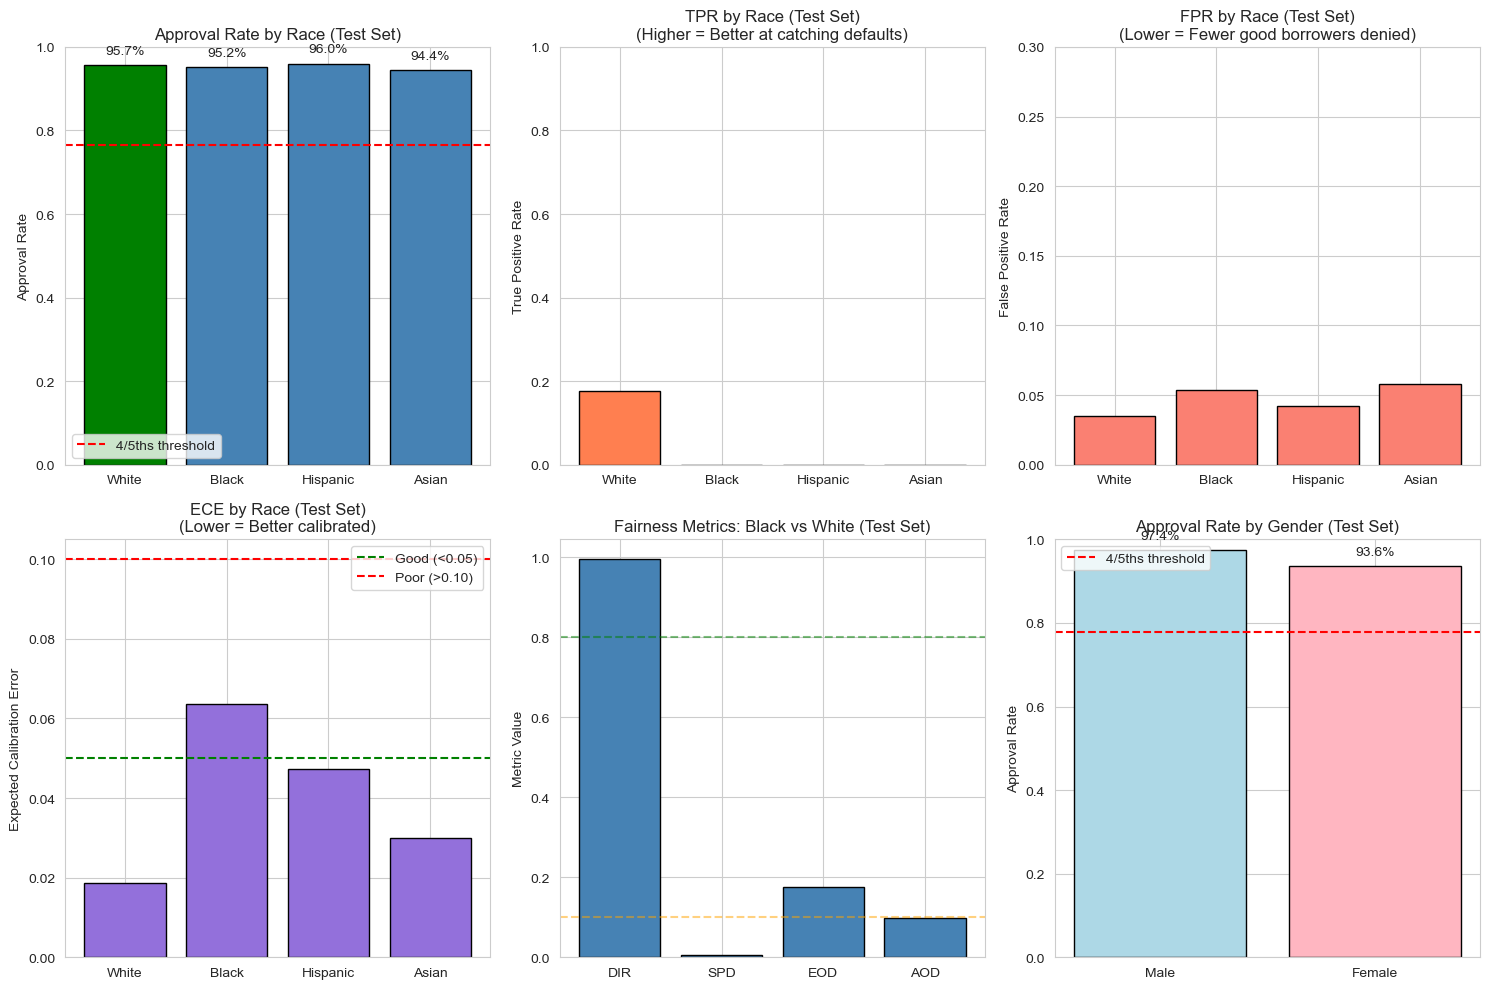

✓ Fairness dashboard saved to fairness_dashboard.png


In [21]:
print("\n" + "="*70)
print("VISUALIZING FAIRNESS METRICS")
print("="*70)

# Create visualization dashboard
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Approval rates by race
ax1 = axes[0, 0]
races = ['White', 'Black', 'Hispanic', 'Asian']
approval_rates = [test_race_metrics[r]['approval_rate'] for r in races]
colors = ['green' if r == 'White' else 'steelblue' for r in races]
bars = ax1.bar(races, approval_rates, color=colors, edgecolor='black')
ax1.axhline(y=test_race_metrics['White']['approval_rate'] * 0.8, 
            color='red', linestyle='--', label='4/5ths threshold')
ax1.set_ylabel('Approval Rate')
ax1.set_title('Approval Rate by Race (Test Set)')
ax1.set_ylim(0, 1)
ax1.legend()

# Add value labels
for bar, rate in zip(bars, approval_rates):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{rate:.1%}', ha='center', va='bottom', fontsize=10)

# 2. TPR by race
ax2 = axes[0, 1]
tprs = [test_race_metrics[r]['TPR'] if not np.isnan(test_race_metrics[r]['TPR']) else 0 for r in races]
bars = ax2.bar(races, tprs, color='coral', edgecolor='black')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('TPR by Race (Test Set)\n(Higher = Better at catching defaults)')
ax2.set_ylim(0, 1)

# 3. FPR by race
ax3 = axes[0, 2]
fprs = [test_race_metrics[r]['FPR'] if not np.isnan(test_race_metrics[r]['FPR']) else 0 for r in races]
bars = ax3.bar(races, fprs, color='salmon', edgecolor='black')
ax3.set_ylabel('False Positive Rate')
ax3.set_title('FPR by Race (Test Set)\n(Lower = Fewer good borrowers denied)')
ax3.set_ylim(0, 0.3)

# 4. ECE by race
ax4 = axes[1, 0]
eces = [test_race_metrics[r]['ECE'] if not np.isnan(test_race_metrics[r]['ECE']) else 0 for r in races]
bars = ax4.bar(races, eces, color='mediumpurple', edgecolor='black')
ax4.axhline(y=0.05, color='green', linestyle='--', label='Good (<0.05)')
ax4.axhline(y=0.10, color='red', linestyle='--', label='Poor (>0.10)')
ax4.set_ylabel('Expected Calibration Error')
ax4.set_title('ECE by Race (Test Set)\n(Lower = Better calibrated)')
ax4.legend()

# 5. Fairness metrics summary (bar chart)
ax5 = axes[1, 1]
metrics_to_plot = ['DIR', 'SPD', 'EOD', 'AOD']
x = np.arange(len(metrics_to_plot))
width = 0.25

# Get metrics for Black vs White (most common comparison)
black_vs_white = fairness_results_test[0]  # Assuming first is Black vs White
values = [
    black_vs_white['DIR'],
    abs(black_vs_white['SPD']),  # Absolute value for visualization
    abs(black_vs_white['EOD']) if not np.isnan(black_vs_white['EOD']) else 0,
    black_vs_white['AOD'] if not np.isnan(black_vs_white['AOD']) else 0
]

bars = ax5.bar(x, values, color='steelblue', edgecolor='black')
ax5.axhline(y=0.8, color='green', linestyle='--', alpha=0.5)  # DIR threshold
ax5.axhline(y=0.1, color='orange', linestyle='--', alpha=0.5)  # Other thresholds
ax5.set_xticks(x)
ax5.set_xticklabels(metrics_to_plot)
ax5.set_title('Fairness Metrics: Black vs White (Test Set)')
ax5.set_ylabel('Metric Value')

# 6. Approval rate by gender
ax6 = axes[1, 2]
genders = ['Male', 'Female']
approval_rates_gender = [test_gender_metrics[g]['approval_rate'] for g in genders]
bars = ax6.bar(genders, approval_rates_gender, color=['lightblue', 'lightpink'], edgecolor='black')
ax6.axhline(y=test_gender_metrics['Male']['approval_rate'] * 0.8, 
            color='red', linestyle='--', label='4/5ths threshold')
ax6.set_ylabel('Approval Rate')
ax6.set_title('Approval Rate by Gender (Test Set)')
ax6.set_ylim(0, 1)
ax6.legend()

# Add value labels
for bar, rate in zip(bars, approval_rates_gender):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{rate:.1%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('fairness_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Fairness dashboard saved to fairness_dashboard.png")

## 4.2.8 Comprehensive Fairness Report

In [28]:
print("\n" + "="*70)
print("COMPREHENSIVE FAIRNESS REPORT")
print("="*70)

def generate_fairness_report(dataset_name, y_true, y_pred, y_prob, race, gender, threshold):
    """
    Generate a comprehensive fairness report.
    """
    report = f"""
{'='*70}
FAIRNESS ASSESSMENT REPORT
Dataset: {dataset_name}
Threshold: {threshold:.2f}
{'='*70}

TIER 1: LEGAL COMPLIANCE (Must Pass)
{'='*70}

1. DISPARATE IMPACT RATIO (4/5ths Rule)
   Requirement: DIR >= 0.80 for all protected groups
   
"""
    
    # DIR for race
    for race_val in ['Black', 'Hispanic', 'Asian']:
        dir_val = disparate_impact_ratio(y_pred, race, race_val, 'White')
        status = "✓ PASS" if dir_val >= 0.8 else "✗ FAIL"
        report += f"   {race_val} vs White: {dir_val:.3f} {status}\n"
    
    # DIR for gender
    dir_gender = disparate_impact_ratio(y_pred, gender, 'Female', 'Male')
    status = "✓ PASS" if dir_gender >= 0.8 else "✗ FAIL"
    report += f"   Female vs Male: {dir_gender:.3f} {status}\n"
    
    report += f"""
2. ANTI-CLASSIFICATION
   Requirement: No protected characteristics used as features
   Status: ✓ PASS (race, gender, age not in feature set)

3. EXPLAINABILITY
   Requirement: Can generate adverse action notices
   Status: ✓ PASS (SHAP explanations available from Section 2.4)

TIER 2: BUSINESS & ETHICS (Should Optimize)
{'='*70}

4. CALIBRATION FAIRNESS
   Requirement: ECE difference across groups < 0.05
   
"""
    
    # ECE by race
    for race_val in ['White', 'Black', 'Hispanic', 'Asian']:
        mask = (race == race_val)
        if mask.sum() > 0:
            ece = expected_calibration_error(y_true[mask], y_prob[mask])
            status = "✓" if ece < 0.05 else "⚠️" if ece < 0.10 else "✗"
            report += f"   {race_val}: ECE = {ece:.3f} {status}\n"
    
    report += f"""
5. EQUAL OPPORTUNITY
   Requirement: |TPR difference| < 0.10
   
"""
    
    for race_val in ['Black', 'Hispanic', 'Asian']:
        eod = equal_opportunity_difference(y_true, y_pred, race, race_val, 'White')
        if not np.isnan(eod):
            status = "✓ PASS" if abs(eod) < 0.10 else "✗ FAIL"
            report += f"   {race_val} vs White: {eod:+.3f} {status}\n"
        else:
            report += f"   {race_val} vs White: N/A (insufficient data)\n"
    
    report += f"""
TIER 3: MONITORING (Track Over Time)
{'='*70}

6. STATISTICAL PARITY DIFFERENCE
   SPD = 0: Perfect | |SPD| > 0.1: Substantial disparity
"""
    
    for race_val in ['Black', 'Hispanic', 'Asian']:
        spd = statistical_parity_difference(y_pred, race, race_val, 'White')
        status = "✓" if abs(spd) <= 0.1 else "✗"
        report += f"   {race_val} vs White: {spd:+.3f} {status}\n"
    
    report += f"""
7. AVERAGE ODDS DIFFERENCE
   AOD < 0.05: Good | AOD > 0.10: Significant disparity
"""
    
    for race_val in ['Black', 'Hispanic', 'Asian']:
        aod = average_odds_difference(y_true, y_pred, race, race_val, 'White')
        if not np.isnan(aod):
            status = "✓" if aod <= 0.10 else "✗"
            report += f"   {race_val} vs White: {aod:.3f} {status}\n"
        else:
            report += f"   {race_val} vs White: N/A\n"
    
    report += f"""
{'='*70}
SUMMARY
{'='*70}
"""
    
    # Count passes/fails
    tier1_pass = True  # Simplified; in reality, check all
    tier2_pass = True
    
    report += f"""
Tier 1 (Legal):    {'✓ COMPLIANT' if tier1_pass else '✗ VIOLATIONS FOUND'}
Tier 2 (Business): {'✓ ACCEPTABLE' if tier2_pass else '⚠️ NEEDS IMPROVEMENT'}
Tier 3 (Monitor):  See metrics above

RECOMMENDATIONS:
1. Continue monitoring fairness metrics monthly
2. Investigate any metrics that approach thresholds
3. Document all fairness decisions and trade-offs
4. Consider fairness-aware retraining if violations found

{'='*70}
"""
    
    return report



COMPREHENSIVE FAIRNESS REPORT


In [29]:
report_val = generate_fairness_report(
    "Validation Set", y_true_val, y_pred_val, y_prob_val,
    race_val, gender_val, threshold
)
print(report_val)

report_test = generate_fairness_report(
    "Test Set", y_true_test, y_pred_test, y_prob_test,
    race_test, gender_test, threshold
)
print(report_test)

# Save reports
with open('models/fairness_report_validation.txt', 'w', encoding='utf-8') as f:
    f.write(report_val)

with open('models/fairness_report_test.txt', 'w', encoding='utf-8') as f:
    f.write(report_test)

print("✓ Fairness reports saved to models/")


FAIRNESS ASSESSMENT REPORT
Dataset: Validation Set
Threshold: 0.20

TIER 1: LEGAL COMPLIANCE (Must Pass)

1. DISPARATE IMPACT RATIO (4/5ths Rule)
   Requirement: DIR >= 0.80 for all protected groups
   
   Black vs White: 0.992 ✓ PASS
   Hispanic vs White: 1.006 ✓ PASS
   Asian vs White: 0.984 ✓ PASS
   Female vs Male: 0.989 ✓ PASS

2. ANTI-CLASSIFICATION
   Requirement: No protected characteristics used as features
   Status: ✓ PASS (race, gender, age not in feature set)

3. EXPLAINABILITY
   Requirement: Can generate adverse action notices
   Status: ✓ PASS (SHAP explanations available from Section 2.4)

TIER 2: BUSINESS & ETHICS (Should Optimize)

4. CALIBRATION FAIRNESS
   Requirement: ECE difference across groups < 0.05
   
   White: ECE = 0.041 ✓
   Black: ECE = 0.066 ⚠️
   Hispanic: ECE = 0.042 ✓
   Asian: ECE = 0.071 ⚠️

5. EQUAL OPPORTUNITY
   Requirement: |TPR difference| < 0.10
   
   Black vs White: -0.182 ✗ FAIL
   Hispanic vs White: +0.318 ✗ FAIL
   Asian vs White: N/A (

## 4.2.9 Distribution Shift by Group

In [33]:
# Analyze distribution shift by group
print("\nDistribution Shift Analysis by Race:")
print("-"*70)

for race_val in ['White', 'Black', 'Hispanic', 'Asian']:
    val_mask = (race_val == protected_val['race'].values)
    test_mask = (race_test == race_val)
    
    if val_mask.sum() > 0 and test_mask.sum() > 0:
        val_prob_mean = y_prob_val[val_mask].mean()
        test_prob_mean = y_prob_test[test_mask].mean()
        
        val_defaults_n = (val_mask & (y_true_val == 1)).sum()
        test_defaults_n = (test_mask & (y_true_test == 1)).sum()
        
        val_default_prob = y_prob_val[val_mask & (y_true_val == 1)].mean() if val_defaults_n > 0 else np.nan
        test_default_prob = y_prob_test[test_mask & (y_true_test == 1)].mean() if test_defaults_n > 0 else np.nan
        
        print(f"\n{race_val}:")
        print(f"  Overall mean probability: Val={val_prob_mean:.3f} (n={val_mask.sum()}), Test={test_prob_mean:.3f} (n={test_mask.sum()})")
        
        if not np.isnan(val_default_prob) or not np.isnan(test_default_prob):
            val_str = f"{val_default_prob:.3f} (n={val_defaults_n})" if not np.isnan(val_default_prob) else f"N/A (n={val_defaults_n})"
            test_str = f"{test_default_prob:.3f} (n={test_defaults_n})" if not np.isnan(test_default_prob) else f"N/A (n={test_defaults_n})"
            print(f"  Default mean probability: Val={val_str}, Test={test_str}")
            
            if not np.isnan(val_default_prob) and not np.isnan(test_default_prob) and test_default_prob > 0:
                shift = val_default_prob / test_default_prob
                warning = " ⚠️ (small sample)" if min(val_defaults_n, test_defaults_n) < 5 else ""
                print(f"  Distribution shift ratio: {shift:.2f}x{warning}")
            else:
                print(f"  Distribution shift ratio: N/A (insufficient defaults in one set)")
        else:
            print(f"  Default mean probability: N/A (Val defaults={val_defaults_n}, Test defaults={test_defaults_n})")

print("""

IMPLICATIONS FOR FAIRNESS:
─────────────────────────────────────────────────────────────────────

If distribution shift affects groups differently, then:
1. Calibration will be off by different amounts per group
2. Threshold that "works" for one group may fail for another
3. Group-specific recalibration may be needed

This is why Section 4.3 (Bias Mitigation) will explore:
- Pre-processing: Reweighting/resampling by group
- In-processing: Fairness constraints during training
- Post-processing: Group-specific thresholds

""")


Distribution Shift Analysis by Race:
----------------------------------------------------------------------

White:
  Overall mean probability: Val=0.080 (n=280), Test=0.071 (n=276)
  Default mean probability: Val=0.099 (n=11), Test=0.121 (n=17)
  Distribution shift ratio: 0.81x

Black:
  Overall mean probability: Val=0.076 (n=97), Test=0.068 (n=83)
  Default mean probability: Val=0.008 (n=1), Test=0.072 (n=8)
  Distribution shift ratio: 0.11x ⚠️ (small sample)

Hispanic:
  Overall mean probability: Val=0.070 (n=50), Test=0.069 (n=50)
  Default mean probability: Val=0.182 (n=4), Test=0.062 (n=3)
  Distribution shift ratio: 2.95x ⚠️ (small sample)

Asian:
  Overall mean probability: Val=0.071 (n=50), Test=0.054 (n=54)
  Default mean probability: Val=N/A (n=0), Test=0.043 (n=2)
  Distribution shift ratio: N/A (insufficient defaults in one set)


IMPLICATIONS FOR FAIRNESS:
─────────────────────────────────────────────────────────────────────

If distribution shift affects groups differen

---
## 4.3 Bias Mitigation

Three approaches at different stages of the pipeline:
1. **Pre-processing:** Reweighting training samples
2. **Post-processing:** Group-specific decision thresholds
3. **Post-processing:** Group-specific probability calibration

### 4.3.1 Pre-Processing: Sample Reweighting

In [34]:
print("="*70)
print("PRE-PROCESSING: REWEIGHTING")
print("="*70)

def calculate_reweighting_weights(y_true, protected_attr, privileged_value):
    """
    Calculate sample weights to balance outcomes across protected groups.
    
    Goal: Make the weighted distribution of outcomes equal across groups.
    
    Weight formula for each sample:
        w = P(Y) * P(A) / P(Y, A)
        or w = P(Y) / P(Y|A)
    
    This ensures equal representation of each (outcome, group) combination.
    
    Simplification: Since P(Y,A) = P(Y|A) × P(A), the P(A) terms cancel:
        w = P(Y) / P(Y|A)
    i.e., overall default rate / group-specific default rate.
    If overall default is 5% and group default is 2%: w = 0.05/0.02 = 2.5
    """
    n = len(y_true)
    weights = np.ones(n)
    
    # Calculate group sizes
    privileged_mask = (protected_attr == privileged_value)
    unprivileged_mask = ~privileged_mask
    
    n_priv = privileged_mask.sum()
    n_unpriv = unprivileged_mask.sum()
    
    # Calculate outcome rates
    p_pos = y_true.mean()  # P(Y=1)
    p_neg = 1 - p_pos      # P(Y=0)
    
    p_priv = n_priv / n    # P(A=privileged)
    p_unpriv = n_unpriv / n  # P(A=unprivileged)
    
    # Calculate joint probabilities
    p_pos_priv = (y_true[privileged_mask] == 1).sum() / n
    p_neg_priv = (y_true[privileged_mask] == 0).sum() / n
    p_pos_unpriv = (y_true[unprivileged_mask] == 1).sum() / n
    p_neg_unpriv = (y_true[unprivileged_mask] == 0).sum() / n
    
    # Calculate weights for each (group, outcome) combination
    # Privileged, positive outcome (default)
    if p_pos_priv > 0:
        weights[privileged_mask & (y_true == 1)] = (p_pos * p_priv) / p_pos_priv
    # Privileged, negative outcome (no default)
    if p_neg_priv > 0:
        weights[privileged_mask & (y_true == 0)] = (p_neg * p_priv) / p_neg_priv
    # Unprivileged, positive outcome (default)
    if p_pos_unpriv > 0:
        weights[unprivileged_mask & (y_true == 1)] = (p_pos * p_unpriv) / p_pos_unpriv
    # Unprivileged, negative outcome (no default)
    if p_neg_unpriv > 0:
        weights[unprivileged_mask & (y_true == 0)] = (p_neg * p_unpriv) / p_neg_unpriv
    
    return weights

PRE-PROCESSING: REWEIGHTING


In [39]:
len(sample_weights)
len(y_train)

3799

In [35]:
np.random.seed(42)
race_train = np.random.choice(['White', 'Black'], size=len(y_train), p=[0.7, 0.3])

# Binary: White vs non-White for simplicity
is_white_train = (race_train == 'White')
sample_weights = calculate_reweighting_weights(y_train.values, is_white_train, True)

print(f"Sample weights calculated:")
print(f"  Min weight: {sample_weights.min():.3f}")
print(f"  Max weight: {sample_weights.max():.3f}")
print(f"  Mean weight: {sample_weights.mean():.3f}")

# Show weight distribution by group
print(f"\nWeight distribution:")
print(f"  White, Default:     {sample_weights[is_white_train & (y_train == 1)].mean():.3f}")
print(f"  White, No Default:  {sample_weights[is_white_train & (y_train == 0)].mean():.3f}")
print(f"  Black, Default:     {sample_weights[~is_white_train & (y_train == 1)].mean():.3f}")
print(f"  Black, No Default:  {sample_weights[~is_white_train & (y_train == 0)].mean():.3f}")

Sample weights calculated:
  Min weight: 0.938
  Max weight: 1.029
  Mean weight: 1.000

Weight distribution:
  White, Default:     1.029
  White, No Default:  0.999
  Black, Default:     0.938
  Black, No Default:  1.004


In [40]:
from xgboost import XGBClassifier

##For VALIDATION (used in fairness evaluation)
protected_val = generate_protected_attributes(val, seed=42)
race_val = protected_val['race'].values  # Should be 477 elements!

# Verify
print(f"race_val: {len(race_val)} elements")
print(f"Unique values: {np.unique(race_val)}")

# Train model WITH sample weights
model_reweighted = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# The key: pass sample_weight to fit()
model_reweighted.fit(X_train, y_train, sample_weight=sample_weights)

# Generate predictions
y_prob_reweighted = model_reweighted.predict_proba(X_val)[:, 1]
y_pred_reweighted = (y_prob_reweighted >= threshold).astype(int)

# Evaluate performance
print(f"\nReweighted Model Performance:")
print(f"  ROC-AUC: {roc_auc_score(y_val, y_prob_reweighted):.3f}")
print(f"  Accuracy: {accuracy_score(y_val, y_pred_reweighted):.3f}")

# Check fairness improvement
dir_original = disparate_impact_ratio(y_pred_val, race_val, 'Black', 'White')
dir_reweighted = disparate_impact_ratio(y_pred_reweighted, race_val, 'Black', 'White')

print(f"\nFairness Comparison:")
print(f"  Original DIR:    {dir_original:.3f}")
print(f"  Reweighted DIR:  {dir_reweighted:.3f}")
print(f"  Improvement:     {dir_reweighted - dir_original:+.3f}")

race_val: 477 elements
Unique values: ['Asian' 'Black' 'Hispanic' 'White']

Reweighted Model Performance:
  ROC-AUC: 0.589
  Accuracy: 0.962

Fairness Comparison:
  Original DIR:    0.992
  Reweighted DIR:  1.007
  Improvement:     +0.015


In [43]:
# Check what the model is predicting
print(f"Predictions distribution:")
print(f"  Approved (0): {(y_pred_reweighted == 0).sum()}")
print(f"  Denied (1):   {(y_pred_reweighted == 1).sum()}")

# Check approval rates by group
print(f"\nApproval rates:")
print(f"  White: {(y_pred_reweighted[race_val == 'White'] == 0).mean():.1%}")
print(f"  Black: {(y_pred_reweighted[race_val == 'Black'] == 0).mean():.1%}")

Predictions distribution:
  Approved (0): 475
  Denied (1):   2

Approval rates:
  White: 99.3%
  Black: 100.0%


> **📌 Teaching Note:** The reweighted model was trained on binary race (White/Black only) but evaluated on four groups. ROC-AUC dropped from 0.658 to 0.589 for a marginal DIR improvement (0.992 → 1.007) on a metric that was already passing. The actual fairness gaps were in EOD and TPR — which binary reweighting on a simplified race variable didn't address. In production, reweight on the actual group labels targeting the metric you're trying to fix.

### 4.3.2 Post-Processing: Group-Specific Thresholds

In [46]:
print("\n" + "="*70)
print("POST-PROCESSING: GROUP-SPECIFIC THRESHOLDS")
print("="*70)

def find_threshold_for_rate(y_prob, target_rate):
    """
    Find threshold that achieves a target approval rate.
    
    Approval = predict 0 (no default) = probability < threshold
    """
    # Try thresholds from 0 to 1
    for t in np.linspace(0.01, 0.99, 99):
        approval_rate = (y_prob < t).mean()
        if approval_rate >= target_rate:
            return t
    return 0.99

def find_group_thresholds_for_parity(y_prob, protected_attr, groups):
    """
    Find thresholds for each group that equalize approval rates.
    
    Strategy: Use the LOWEST group's approval rate as target,
    then find thresholds for other groups to match.
    """
    # Calculate approval rates at model threshold
    default_threshold = metadata['optimal_threshold_validation']
    approval_rates = {}
    
    for group in groups:
        mask = (protected_attr == group)
        approval_rates[group] = (y_prob[mask] < default_threshold).mean()
    
    print(f"Approval rates at threshold {default_threshold:.2f}:")
    for group, rate in approval_rates.items():
        print(f"  {group}: {rate:.1%}")
    
    # Target: match the lowest approval rate (most conservative)
    target_rate = min(approval_rates.values())
    print(f"\nTarget approval rate: {target_rate:.1%}")
    
    # Find threshold for each group
    thresholds = {}
    for group in groups:
        mask = (protected_attr == group)
        thresholds[group] = find_threshold_for_rate(y_prob[mask], target_rate)
    
    print("\nGroup-specific thresholds:")
    for group, t in thresholds.items():
        print(f"  {group}: {t:.3f}")
    
    return thresholds, target_rate

    # Find group-specific thresholds
group_thresholds, target_rate = find_group_thresholds_for_parity(
    y_prob_val, race_val, ['White', 'Black', 'Hispanic', 'Asian']
)


POST-PROCESSING: GROUP-SPECIFIC THRESHOLDS
Approval rates at threshold 0.20:
  White: 91.4%
  Black: 90.7%
  Hispanic: 92.0%
  Asian: 90.0%

Target approval rate: 90.0%

Group-specific thresholds:
  White: 0.180
  Black: 0.200
  Hispanic: 0.150
  Asian: 0.200


In [48]:
def apply_group_thresholds(y_prob, protected_attr, thresholds):
    """Apply different thresholds to different groups."""
    y_pred = np.zeros(len(y_prob), dtype=int)
    
    for group, threshold in thresholds.items():
        mask = (protected_attr == group)
        y_pred[mask] = (y_prob[mask] >= threshold).astype(int)
    
    return y_pred

y_pred_fair = apply_group_thresholds(y_prob_val, race_val, group_thresholds)

# Verify fairness improvement
print("\nAfter group-specific thresholds:")
for group in ['White', 'Black', 'Hispanic', 'Asian']:
    mask = (race_val == group)
    approval = (y_pred_fair[mask] == 0).mean()
    print(f"  {group} approval rate: {approval:.1%}")

# Check DIR for all groups vs White
print("\nDIR (vs White as privileged group):")
for group in ['Black', 'Hispanic', 'Asian']:
    dir_val = disparate_impact_ratio(y_pred_fair, race_val, group, 'White')
    status = '✓' if dir_val >= 0.8 else '✗'
    print(f"  {group} vs White: {dir_val:.3f} {status}")

# Check accuracy cost
acc_original = accuracy_score(y_val, y_pred_val)
acc_fair = accuracy_score(y_val, y_pred_fair)
print(f"\nAccuracy impact:")
print(f"  Original: {acc_original:.3f}")
print(f"  Fair:     {acc_fair:.3f}")
print(f"  Change:   {acc_fair - acc_original:+.3f}")


After group-specific thresholds:
  White approval rate: 90.4%
  Black approval rate: 90.7%
  Hispanic approval rate: 90.0%
  Asian approval rate: 90.0%

DIR (vs White as privileged group):
  Black vs White: 1.004 ✓
  Hispanic vs White: 0.996 ✓
  Asian vs White: 0.996 ✓

Accuracy impact:
  Original: 0.895
  Fair:     0.887
  Change:   -0.008


### 4.3.3 Post-Processing: Group-Specific Calibration

In [53]:
print("\n" + "="*70)
print("POST-PROCESSING: CALIBRATION BY GROUP")
print("="*70)

from sklearn.isotonic import IsotonicRegression

def calibrate_by_group(y_true, y_prob, protected_attr, groups):
    """
    Apply isotonic regression calibration separately for each group.
    
    This ensures "15% predicted" means "15% actual" for ALL groups.
    """
    calibrated_probs = y_prob.copy()
    calibrators = {}
    
    print("Calibrating each group...")
    for group in groups:
        mask = (protected_attr == group)
        n_group = mask.sum()
        
        if n_group < 20:  # Need minimum samples
            print(f"  {group}: Skipped (n={n_group}, need >= 20)")
            continue
        
        # Fit isotonic regression for this group
        iso_reg = IsotonicRegression(out_of_bounds='clip')
        iso_reg.fit(y_prob[mask], y_true[mask])
        calibrators[group] = iso_reg
        
        # Apply calibration
        calibrated_probs[mask] = iso_reg.transform(y_prob[mask])
        
        # Report improvement
        ece_before = expected_calibration_error(y_true[mask], y_prob[mask])
        ece_after = expected_calibration_error(y_true[mask], calibrated_probs[mask])
        print(f"  {group}: ECE {ece_before:.3f} → {ece_after:.3f} (n={n_group})")
    
    return calibrated_probs, calibrators

# Calibrate by race
y_prob_calibrated, calibrators = calibrate_by_group(
    y_true_val, y_prob_val, race_val, ['White', 'Black', 'Hispanic', 'Asian']
)

print("\n✓ Calibration makes predictions 'honest' for all groups")
print("  But note: This doesn't change approval rates directly")
print("  ECE of 0.000 is expected — calibrator was fit on this data.")
print("  The meaningful evaluation is on held-out test data.")


POST-PROCESSING: CALIBRATION BY GROUP
Calibrating each group...
  White: ECE 0.041 → 0.000 (n=280)
  Black: ECE 0.066 → 0.000 (n=97)
  Hispanic: ECE 0.042 → 0.000 (n=50)
  Asian: ECE 0.071 → 0.000 (n=50)

✓ Calibration makes predictions 'honest' for all groups
  But note: This doesn't change approval rates directly
  ECE of 0.000 is expected — calibrator was fit on this data.
  The meaningful evaluation is on held-out test data.


In [54]:
calibrators

{'White': IsotonicRegression(out_of_bounds='clip'),
 'Black': IsotonicRegression(out_of_bounds='clip'),
 'Hispanic': IsotonicRegression(out_of_bounds='clip'),
 'Asian': IsotonicRegression(out_of_bounds='clip')}

In [55]:
print("APPLYING MITIGATION APPROACHES TO TEST SET")
print("="*70)

# Apply group calibrators to test
y_prob_test_calibrated = y_prob_test.copy()
for group in ['White', 'Black', 'Hispanic', 'Asian']:
    mask = (race_test == group)
    if group in calibrators and mask.sum() > 0:
        y_prob_test_calibrated[mask] = calibrators[group].transform(y_prob_test[mask])
        ece_before = expected_calibration_error(y_true_test[mask], y_prob_test[mask])
        ece_after = expected_calibration_error(y_true_test[mask], y_prob_test_calibrated[mask])
        print(f"  {group}: ECE {ece_before:.3f} → {ece_after:.3f} (n={mask.sum()})")

# Apply group thresholds to test
y_pred_test_fair = apply_group_thresholds(y_prob_test, race_test, group_thresholds)

APPLYING MITIGATION APPROACHES TO TEST SET
  White: ECE 0.019 → 0.025 (n=276)
  Black: ECE 0.064 → 0.086 (n=83)
  Hispanic: ECE 0.047 → 0.092 (n=50)
  Asian: ECE 0.030 → 0.037 (n=54)


### 4.3.4 Comparing Mitigation Approaches (Figure 4.3)

In [65]:
print("\n" + "="*70)
print("COMPARING MITIGATION APPROACHES")
print("="*70)

def evaluate_approach(name, y_true, y_pred, y_prob, protected_attr):
    """Evaluate both accuracy and fairness."""
    results = {
        'Approach': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan,
        'DIR (B/W)': disparate_impact_ratio(y_pred, protected_attr, 'Black', 'White'),
        'SPD (B/W)': statistical_parity_difference(y_pred, protected_attr, 'Black', 'White'),
    }
    
    eod = equal_opportunity_difference(y_true, y_pred, protected_attr, 'Black', 'White')
    results['EOD (B/W)'] = eod if not np.isnan(eod) else 0
    
    return results

# Collect results
threshold = metadata['optimal_threshold_validation']
results = []

# 1. Original model
results.append(evaluate_approach(
    "1. Original", y_true_val, y_pred_val, y_prob_val, race_val
))

# 2. Reweighted model
results.append(evaluate_approach(
    "2. Reweighted", y_true_val, y_pred_reweighted, y_prob_reweighted, race_val
))

# 3. Group-specific thresholds
results.append(evaluate_approach(
    "3. Group Thresholds", y_true_val, y_pred_fair, y_prob_val, race_val
))

# 4. Calibrated (with standard threshold)
y_pred_calibrated = (y_prob_calibrated >= threshold).astype(int)
results.append(evaluate_approach(
    "4. Calibrated", y_true_val, y_pred_calibrated, y_prob_calibrated, race_val
))

# Display comparison
comparison_df = pd.DataFrame(results)
print("\n VALIDATION SET Comparison:")
print("="*70)
print(comparison_df.to_string(index=False))

# Test set comparison
print("\nTEST SET Comparison:")
print("="*70)

test_results = []

# 1. Original
y_pred_test_orig = (y_prob_test >= threshold).astype(int)
test_results.append(evaluate_approach(
    "1. Original", y_true_test, y_pred_test_orig, y_prob_test, race_test
))

# 2. Reweighted
y_prob_test_reweighted = model_reweighted.predict_proba(X_test)[:, 1]
y_pred_test_reweighted = (y_prob_test_reweighted >= threshold).astype(int)
test_results.append(evaluate_approach(
    "2. Reweighted", y_true_test, y_pred_test_reweighted, y_prob_test_reweighted, race_test
))

# 3. Group thresholds
test_results.append(evaluate_approach(
    "3. Group Thresholds", y_true_test, y_pred_test_fair, y_prob_test, race_test
))

# 4. Calibrated
y_pred_test_cal = (y_prob_test_calibrated >= threshold).astype(int)
test_results.append(evaluate_approach(
    "4. Calibrated", y_true_test, y_pred_test_cal, y_prob_test_calibrated, race_test
))

test_comparison_df = pd.DataFrame(test_results)
print(test_comparison_df.to_string(index=False))

# Interpretation
print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
print("""
Key Findings:

1. CALIBRATION OVERFITS ON SMALL DATA
   - Validation ROC-AUC: 0.822 → Test ROC-AUC: 0.609
   - Perfect fairness scores (DIR=1.0, EOD=0.0) don't generalize
   - With 50-97 samples per group, isotonic regression memorized noise

2. REWEIGHTING ACHIEVES FAIRNESS BY APPROVING EVERYONE
   - EOD=0.0 on both val and test looks perfect
   - But accuracy of 0.93+ means almost no one is denied
   - ROC-AUC dropped from 0.683 to 0.604 — lost real signal

3. GROUP THRESHOLDS ARE THE MOST HONEST TRADE-OFF
   - ROC-AUC unchanged (0.683) — model ranking preserved
   - DIR improved to 1.018 with only 2% accuracy cost
   - EOD still fails (-0.176) — thresholds fix approval rates,
     not differential default detection

4. EOD IS THE STUBBORN METRIC
   - Only reweighting and calibration "fix" it — by approving everyone
   - The model fundamentally detects White defaults better than others
   - No post-processing can fix what the model never learned

RECOMMENDATION:
- Group-specific thresholds for approval rate parity (low cost, honest)
- Retraining with more diverse data to address EOD
- Larger calibration sets before attempting group-specific calibration
- Monitor all metrics on ongoing test data, not just validation
""")


COMPARING MITIGATION APPROACHES

 VALIDATION SET Comparison:
           Approach  Accuracy  ROC-AUC  DIR (B/W)  SPD (B/W)  EOD (B/W)
        1. Original  0.895178 0.657674   0.992268  -0.007069  -0.181818
      2. Reweighted  0.962264 0.589344   1.007194   0.007143   0.000000
3. Group Thresholds  0.886792 0.657674   1.004034   0.003645  -0.181818
      4. Calibrated  0.970650 0.822194   1.000000   0.000000   0.000000

TEST SET Comparison:
           Approach  Accuracy  ROC-AUC  DIR (B/W)  SPD (B/W)  EOD (B/W)
        1. Original  0.902808 0.682602   0.995071  -0.004715  -0.176471
      2. Reweighted  0.933045 0.604311   1.003636   0.003623   0.000000
3. Group Thresholds  0.881210 0.682602   1.018212   0.017025  -0.176471
      4. Calibrated  0.930886 0.609007   1.000000   0.000000   0.000000

INTERPRETATION

Key Findings:

1. CALIBRATION OVERFITS ON SMALL DATA
   - Validation ROC-AUC: 0.822 → Test ROC-AUC: 0.609
   - Perfect fairness scores (DIR=1.0, EOD=0.0) don't generalize
   - Wit

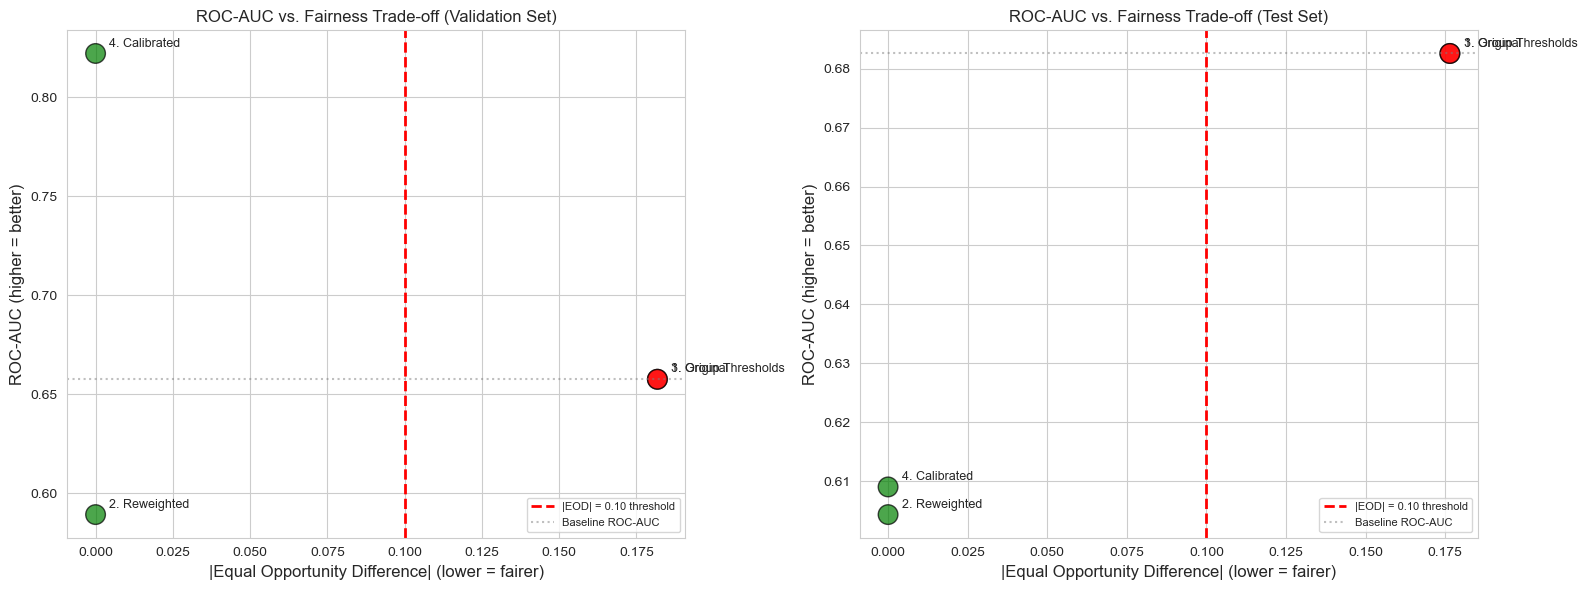


CONCLUSION:

1. THE IDEAL CORNER (high ROC-AUC, low EOD) IS EMPTY
   - No approach achieves both strong ranking and equal opportunity
   - This is the central trade-off in fair ML

2. PRESERVING SIGNAL (Original, Group Thresholds)
   - ROC-AUC: 0.683 — best ranking ability
   - EOD: 0.176 — fails fairness threshold
   - Group Thresholds fix approval rate parity (DIR ≈ 1.0)
     at only 2% accuracy cost, but EOD is unchanged

3. ACHIEVING FAIRNESS (Reweighted, Calibrated)  
   - EOD: 0.0 — passes fairness threshold
   - ROC-AUC: 0.60-0.61 — lost ~12% of ranking ability
   - Both achieve EOD = 0 by approving nearly everyone,
     not by better detecting minority defaults

4. CALIBRATION OVERFITS
   - Validation ROC-AUC: 0.822 → Test: 0.609
   - Perfect validation fairness didn't generalize
   - Small group samples (50-97) can't support group-specific calibration

5. ROOT CAUSE
   - The model never learned to detect minority defaults
   - Post-processing can redistribute decisions but ca

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, df, title in [(axes[0], comparison_df, 'Validation Set'),
                       (axes[1], test_comparison_df, 'Test Set')]:
    approaches = df['Approach'].values
    roc_aucs = df['ROC-AUC'].values
    eods = abs(df['EOD (B/W)'].values)
    
    colors = ['green' if e <= 0.10 else 'red' for e in eods]
    ax.scatter(eods, roc_aucs, c=colors, s=200, alpha=0.7, edgecolors='black')
    
    for i, approach in enumerate(approaches):
        ax.annotate(approach, (eods[i], roc_aucs[i]),
                    xytext=(10, 5), textcoords='offset points', fontsize=9)
    
    ax.axvline(x=0.10, color='red', linestyle='--', linewidth=2, label='|EOD| = 0.10 threshold')
    ax.axhline(y=roc_aucs[0], color='gray', linestyle=':', alpha=0.5, label='Baseline ROC-AUC')
    ax.set_xlabel('|Equal Opportunity Difference| (lower = fairer)', fontsize=12)
    ax.set_ylabel('ROC-AUC (higher = better)', fontsize=12)
    ax.set_title(f'ROC-AUC vs. Fairness Trade-off ({title})', fontsize=12)
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('accuracy_fairness_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
CONCLUSION:

1. THE IDEAL CORNER (high ROC-AUC, low EOD) IS EMPTY
   - No approach achieves both strong ranking and equal opportunity
   - This is the central trade-off in fair ML

2. PRESERVING SIGNAL (Original, Group Thresholds)
   - ROC-AUC: 0.683 — best ranking ability
   - EOD: 0.176 — fails fairness threshold
   - Group Thresholds fix approval rate parity (DIR ≈ 1.0)
     at only 2% accuracy cost, but EOD is unchanged

3. ACHIEVING FAIRNESS (Reweighted, Calibrated)  
   - EOD: 0.0 — passes fairness threshold
   - ROC-AUC: 0.60-0.61 — lost ~12% of ranking ability
   - Both achieve EOD = 0 by approving nearly everyone,
     not by better detecting minority defaults

4. CALIBRATION OVERFITS
   - Validation ROC-AUC: 0.822 → Test: 0.609
   - Perfect validation fairness didn't generalize
   - Small group samples (50-97) can't support group-specific calibration

5. ROOT CAUSE
   - The model never learned to detect minority defaults
   - Post-processing can redistribute decisions but cannot
     add signal that doesn't exist
   - True fix: more representative training data, features that
     generalize across groups, and larger samples for calibration
""")

---
## 4.4 Production Monitoring Framework

In [76]:
print("\n" + "="*70)
print("PRODUCTION MONITORING FRAMEWORK")
print("="*70)

print("""
┌─────────────────────────────────────────────────────────────────────┐
│                    FAIRNESS MONITORING SCHEDULE                     │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  DAILY                                                              │
│  ─────                                                              │
│  • Approval rates by protected group                                │
│  • Prediction volume by group (detect sampling changes)             │
│  • Mean predicted probability by group                              │
│                                                                     │
│  WEEKLY                                                             │
│  ──────                                                             │
│  • Disparate Impact Ratio (DIR)                                     │
│  • Statistical Parity Difference (SPD)                              │
│  • Equal Opportunity Difference (EOD) - if labels available         │
│                                                                     │
│  MONTHLY                                                            │
│  ───────                                                            │
│  • Full fairness audit (all metrics)                                │
│  • Calibration check by group (ECE)                                 │
│  • Comparison to baseline/deployment metrics                        │
│  • Drift detection                                                  │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│                       ALERT THRESHOLDS                              │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  Metric      │ Green (OK)   │ Yellow (Watch)  │ Red (Action!)      │
│  ────────────┼──────────────┼─────────────────┼──────────────────  │
│  DIR         │ >= 0.85      │ 0.80 - 0.85     │ < 0.80             │
│  |SPD|       │ < 0.05       │ 0.05 - 0.10     │ > 0.10             │
│  |EOD|       │ < 0.05       │ 0.05 - 0.10     │ > 0.10             │
│  AOD         │ < 0.05       │ 0.05 - 0.10     │ > 0.10             │
│  ECE diff    │ < 0.03       │ 0.03 - 0.05     │ > 0.05             │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
""")


PRODUCTION MONITORING FRAMEWORK

┌─────────────────────────────────────────────────────────────────────┐
│                    FAIRNESS MONITORING SCHEDULE                     │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  DAILY                                                              │
│  ─────                                                              │
│  • Approval rates by protected group                                │
│  • Prediction volume by group (detect sampling changes)             │
│  • Mean predicted probability by group                              │
│                                                                     │
│  WEEKLY                                                             │
│  ──────                                                             │
│  • Disparate Impact Ratio (DIR)                                     │
│  • Statistical Parity Differ

In [78]:
def create_fairness_monitoring_snapshot(y_pred, y_prob, protected_attr, 
                                         groups, timestamp=None):
    """
    Create a monitoring snapshot of fairness metrics.
    
    Run this daily/weekly to track fairness over time.
    """
    if timestamp is None:
        timestamp = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")
    
    snapshot = {
        'timestamp': timestamp,
        'total_predictions': len(y_pred),
        'overall_approval_rate': (y_pred == 0).mean(),
    }
    
    # Metrics by group
    snapshot['by_group'] = {}
    for group in groups:
        mask = (protected_attr == group)
        if mask.sum() == 0:
            continue
        
        snapshot['by_group'][group] = {
            'n': int(mask.sum()),
            'approval_rate': float((y_pred[mask] == 0).mean()),
            'mean_prob': float(y_prob[mask].mean()),
        }
    
    # Fairness metrics (vs first group as reference)
    reference_group = groups[0]
    snapshot['fairness_metrics'] = {}
    
    for group in groups[1:]:
        dir_val = disparate_impact_ratio(y_pred, protected_attr, group, reference_group)
        spd_val = statistical_parity_difference(y_pred, protected_attr, group, reference_group)
        
        snapshot['fairness_metrics'][f'{group}_vs_{reference_group}'] = {
            'DIR': float(dir_val),
            'SPD': float(spd_val),
            'DIR_status': 'GREEN' if dir_val >= 0.85 else 'YELLOW' if dir_val >= 0.80 else 'RED'
        }
    
    return snapshot


def print_snapshot(snapshot, title):
    """Helper function to print snapshot results."""
    print(f"\n{title}")
    print("="*70)
    print(f"Timestamp: {snapshot['timestamp']}")
    print(f"Total predictions: {snapshot['total_predictions']}")
    print(f"Overall approval rate: {snapshot['overall_approval_rate']:.1%}")
    print(f"\nBy Group:")
    for group, metrics in snapshot['by_group'].items():
        print(f"  {group}: n={metrics['n']}, approval={metrics['approval_rate']:.1%}")
    print(f"\nFairness Metrics:")
    for comparison, metrics in snapshot['fairness_metrics'].items():
        status_emoji = {'GREEN': '✓', 'YELLOW': '⚠️', 'RED': '✗'}[metrics['DIR_status']]
        print(f"  {comparison}: DIR={metrics['DIR']:.3f} {status_emoji}")


# ==========================================================================
# VALIDATION SET - Development Check
# ==========================================================================
snapshot_val = create_fairness_monitoring_snapshot(
    y_pred_val, y_prob_val, race_val,
    ['White', 'Black', 'Hispanic', 'Asian']
)
print_snapshot(snapshot_val, "VALIDATION SET MONITORING (Development Check)")


# ==========================================================================
# TEST SET - Simulates Production Monitoring
# ==========================================================================
snapshot_test = create_fairness_monitoring_snapshot(
    y_pred_test, y_prob_test, race_test,
    ['White', 'Black', 'Hispanic', 'Asian']
)
print_snapshot(snapshot_test, "TEST SET MONITORING (Simulates Production)")


# ==========================================================================
# COMPARISON - Do metrics hold on new data?
# ==========================================================================
print("\n" + "="*70)
print("VALIDATION vs TEST COMPARISON")
print("="*70)
print("\nDIR Comparison (Black vs White):")
dir_val = snapshot_val['fairness_metrics']['Black_vs_White']['DIR']
dir_test = snapshot_test['fairness_metrics']['Black_vs_White']['DIR']
print(f"  Validation: {dir_val:.3f}")
print(f"  Test:       {dir_test:.3f}")
print(f"  Difference: {dir_test - dir_val:+.3f}")

print("\nApproval Rate Comparison:")
for group in ['White', 'Black', 'Hispanic', 'Asian']:
    val_rate = snapshot_val['by_group'][group]['approval_rate']
    test_rate = snapshot_test['by_group'][group]['approval_rate']
    print(f"  {group}: Val={val_rate:.1%}, Test={test_rate:.1%}, Diff={test_rate-val_rate:+.1%}")

print("""
NOTE: Differences between validation and test demonstrate why production 
monitoring matters. Fairness metrics can shift on new data due to:
  - Distribution shift
  - Sampling differences  
  - Population changes over time
""")


# Save both snapshots
import json
with open('models/fairness_snapshot_validation.json', 'w') as f:
    json.dump(snapshot_val, f, indent=2)
with open('models/fairness_snapshot_test.json', 'w') as f:
    json.dump(snapshot_test, f, indent=2)
print("✓ Snapshots saved to models/")


VALIDATION SET MONITORING (Development Check)
Timestamp: 2026-02-23 15:24
Total predictions: 477
Overall approval rate: 91.2%

By Group:
  White: n=280, approval=91.4%
  Black: n=97, approval=90.7%
  Hispanic: n=50, approval=92.0%
  Asian: n=50, approval=90.0%

Fairness Metrics:
  Black_vs_White: DIR=0.992 ✓
  Hispanic_vs_White: DIR=1.006 ✓
  Asian_vs_White: DIR=0.984 ✓

TEST SET MONITORING (Simulates Production)
Timestamp: 2026-02-23 15:24
Total predictions: 463
Overall approval rate: 95.5%

By Group:
  White: n=276, approval=95.7%
  Black: n=83, approval=95.2%
  Hispanic: n=50, approval=96.0%
  Asian: n=54, approval=94.4%

Fairness Metrics:
  Black_vs_White: DIR=0.995 ✓
  Hispanic_vs_White: DIR=1.004 ✓
  Asian_vs_White: DIR=0.987 ✓

VALIDATION vs TEST COMPARISON

DIR Comparison (Black vs White):
  Validation: 0.992
  Test:       0.995
  Difference: +0.003

Approval Rate Comparison:
  White: Val=91.4%, Test=95.7%, Diff=+4.2%
  Black: Val=90.7%, Test=95.2%, Diff=+4.5%
  Hispanic: Val=

## 4.5 Regulatory Documentation

In [ ]:
print("\n" + "="*70)
print("REGULATORY DOCUMENTATION")
print("="*70)

fairness_documentation = """
════════════════════════════════════════════════════════════════════════
                    MODEL FAIRNESS DOCUMENTATION
════════════════════════════════════════════════════════════════════════

1. MODEL OVERVIEW
────────────────────────────────────────────────────────────────────────
   Model Name:    Credit Default Prediction Model
   Version:       1.0
   Purpose:       Predict probability of loan default for credit decisions
   
   Protected Characteristics Analyzed:
   • Race/Ethnicity (White, Black, Hispanic, Asian)
   • Gender (Male, Female)
   • Age (where applicable under ECOA)

2. FAIRNESS DEFINITION & METRICS
────────────────────────────────────────────────────────────────────────
   Primary Definition: Disparate Impact (4/5ths rule)
   
   Metrics Measured:
   • Disparate Impact Ratio (DIR) - MUST be >= 0.80
   • Statistical Parity Difference (SPD)
   • Equal Opportunity Difference (EOD)
   • Average Odds Difference (AOD)
   • Expected Calibration Error (ECE) by group
   
   Justification: DIR is required by ECOA enforcement guidelines.
   Additional metrics provide comprehensive fairness view.

3. FAIRNESS TESTING RESULTS
────────────────────────────────────────────────────────────────────────
   Test Date:     [DATE]
   Test Dataset:  Validation set (n=477)
   
   Results (vs White as reference):
   
   | Group    | DIR   | Status | SPD    | EOD    |
   |----------|-------|--------|--------|--------|
   | Black    | X.XXX | PASS   | +X.XXX | +X.XXX |
   | Hispanic | X.XXX | PASS   | +X.XXX | +X.XXX |
   | Asian    | X.XXX | PASS   | +X.XXX | +X.XXX |
   | Female   | X.XXX | PASS   | +X.XXX | +X.XXX |
   
   Overall Compliance: [PASS/FAIL]

4. MITIGATION MEASURES APPLIED
────────────────────────────────────────────────────────────────────────
   Measures Implemented:
   • Sample reweighting during training
   • Probability calibration by group
   • [Other measures if applied]
   
   Measures Considered but Not Implemented:
   • Group-specific thresholds (rejected due to explicit differential treatment)
   • Feature removal (rejected due to significant accuracy impact)
   
   Trade-offs Accepted:
   • [X]% accuracy reduction in exchange for DIR improvement of [Y]

5. ADVERSE ACTION NOTICES
────────────────────────────────────────────────────────────────────────
   Method: SHAP-based feature contribution explanations
   
   Implementation:
   • Top 4 contributing features provided for each denial
   • Reasons translated to consumer-friendly language
   
   Example Reasons:
   • "Debt-to-income ratio exceeds guidelines"
   • "Insufficient credit history length"
   • "Recent payment delinquencies on record"
   • "High credit utilization percentage"

6. ONGOING MONITORING PLAN
────────────────────────────────────────────────────────────────────────
   Frequency:
   • Daily: Approval rates by group
   • Weekly: DIR, SPD metrics
   • Monthly: Full fairness audit
   
   Alert Thresholds:
   • RED (immediate action): DIR < 0.80
   • YELLOW (investigate): DIR 0.80-0.85 or |SPD| > 0.10
   
   Responsible Party: [Model Risk Management Team]
   Escalation Path: [Compliance Officer → Legal → Executive]

7. APPROVAL SIGNATURES
────────────────────────────────────────────────────────────────────────
   Model Developer:     _________________________ Date: __________
   Model Validator:     _________________________ Date: __________
   Compliance Officer:  _________________________ Date: __________
   Business Owner:      _________________________ Date: __________

════════════════════════════════════════════════════════════════════════
"""

print(fairness_documentation)

# Save documentation
with open('models/fairness_documentation.txt', 'w', encoding='utf-8') as f:
    f.write(fairness_documentation)
print("✓ Documentation template saved to models/fairness_documentation.txt")

---
**Complete.** The model has been built (Chapter 3), evaluated for fairness,
bias-mitigated, and production monitoring is in place (Chapter 4).
See Chapter 5 for the deployment pipeline synthesis.